# Analise de Doencas Cardiacas -- Heart Failure Prediction Dataset

**Dataset:** Heart Failure Prediction Dataset (Kaggle / UCI)  
**Variavel Alvo:** `HeartDisease` (0 = Sem doenca | 1 = Com doenca)  

### Justificativa da Escolha

O dataset foi selecionado por reunir dados clinicos reais de pacientes, sendo ideal para:
- Analise exploratoria de variaveis quantitativas (idade, pressao, colesterol) e qualitativas (tipo de dor, ECG);
- Tratamento de dados inconsistentes e valores ausentes mascarados como zero;
- Aplicacao do Teorema de Bayes e algoritmos de classificacao para predicao de doencas cardiacas.



## 1. Importacao das Bibliotecas


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

## 2. Carregamento do Dataset

O dataset foi obtido do [Kaggle -- Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction),  
fruto da combinacao de 5 datasets cardiacos do repositorio UCI Machine Learning.


In [3]:
df = pd.read_csv('heart.csv')
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3. Tratamento e Limpeza dos Dados

### 3.1 Visao Geral Inicial


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


### 3.2 Estatisticas Descritivas Iniciais


In [5]:
df.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### 3.3 Identificacao de Problemas

Observacoes nos dados brutos:
- **`Cholesterol`:** 172 registros com valor **0**, o que e biologicamente impossivel (colesterol = 0 mg/dL nao existe em vida). Esses valores representam dados ausentes mascarados.
- **`RestingBP`:** 1 registro com valor **0** (pressao arterial em repouso de 0 e incompativel com vida).
- **`HeartDisease`:** Variavel alvo corretamente binaria (0/1).


In [6]:

print(f"Cholesterol iguais 0: {(df['Cholesterol'] == 0).sum()} registros")
print(f"RestingBP  iguais 0: {(df['RestingBP']  == 0).sum()} registros")
print("\nValores nulos explicitos:")
print(df.isnull().sum())


Cholesterol iguais 0: 172 registros
RestingBP  iguais 0: 1 registros

Valores nulos explicitos:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


### 3.4 Tratamento de Cholesterol -- Imputacao pela Mediana por Sexo

**Justificativa:** Substituir por zero distorceria fortemente medias e correlacoes. A mediana por grupo (Sexo) é preferivel a mediana global pois captura diferencas fisiologicas conhecidas entre homens e mulheres no perfil lipidico, sem ser sensivel a outliers como a media seria.


In [7]:
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
print(f" Nulos em Cholesterol : {df['Cholesterol'].isnull().sum()}")

 Nulos em Cholesterol : 172


In [8]:

df.groupby('Sex')['Cholesterol'].median()

df['Cholesterol'] = df['Cholesterol'].fillna(
    df.groupby('Sex')['Cholesterol'].transform('median')
)
print(f"\nNulos restantes em Cholesterol: {df['Cholesterol'].isnull().sum()}")



Nulos restantes em Cholesterol: 0


### 3.5 Tratamento de RestingBP -- Imputacao pela Mediana por Sexo

**Justificativa:** Mesmo criterio do Colesterol. Pressao arterial em repouso igual a zero e clinicamente impossivel, sendo um dado ausente mascarado. Imputa-se a mediana por grupo para manter representatividade.


In [9]:
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].fillna(
    df.groupby('Sex')['RestingBP'].transform('median')
)
print(f"Nulos restantes em RestingBP: {df['RestingBP'].isnull().sum()}")


Nulos restantes em RestingBP: 0


### 3.6 Conversao da Variavel Alvo para Booleano

**Justificativa:** A variavel `HeartDisease` representa um estado binario (tem ou nao tem doenca). Converte-la para `bool` torna o codigo mais legivel e semantico.


In [10]:
df['HeartDisease'] = df['HeartDisease'].astype(bool)
print("Tipo atual:", df["HeartDisease"].dtype)
print(df['HeartDisease'].value_counts())


Tipo atual: bool
HeartDisease
True     508
False    410
Name: count, dtype: int64


### 3.7 Verificação de outliers

In [11]:
for col in df.columns:
    if(df[col].dtype == 'int64' or df[col].dtype == 'float64'):
        mediana=df[col].median()
        media=df[col].mean()
        moda=df[col].mode()[0]
        maximo=df[col].max()
        minimo=df[col].min()
        print(f"{col}:\n-Mediana: {mediana},\n-Média: {media}\n-Moda: {moda},\n-Máximo: {maximo}\n-Mínimo: {minimo}\n")

Age:
-Mediana: 54.0,
-Média: 53.510893246187365
-Moda: 54,
-Máximo: 77
-Mínimo: 28

RestingBP:
-Mediana: 130.0,
-Média: 132.53812636165577
-Moda: 120.0,
-Máximo: 200.0
-Mínimo: 80.0

Cholesterol:
-Mediana: 234.0,
-Média: 242.81045751633988
-Moda: 234.0,
-Máximo: 603.0
-Mínimo: 85.0

FastingBS:
-Mediana: 0.0,
-Média: 0.23311546840958605
-Moda: 0,
-Máximo: 1
-Mínimo: 0

MaxHR:
-Mediana: 138.0,
-Média: 136.80936819172112
-Moda: 150,
-Máximo: 202
-Mínimo: 60

Oldpeak:
-Mediana: 0.6,
-Média: 0.8873638344226579
-Moda: 0.0,
-Máximo: 6.2
-Mínimo: -2.6




**-Todos esses valores são possíveis clinicamente, então não devem ser tratados!**

### 3.8 Verificacao Final da Limpeza


In [12]:
print("=== Nulos apos tratamento ===")
print(df.isnull().sum())
print(f"\nShape final: {df.shape}")
df.describe()


=== Nulos apos tratamento ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Shape final: (918, 12)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,242.810458,0.233115,136.809368,0.887364
std,9.432617,17.990127,53.474043,0.423046,25.460334,1.066570
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,234.000000,0.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000


## 4. Analise Exploratoria de Dados (EDA)

### 4.1 Distribuicao da Variavel Alvo

**Objetivo:** Verificar o balanceamento das classes para entender o contexto da classificacao.


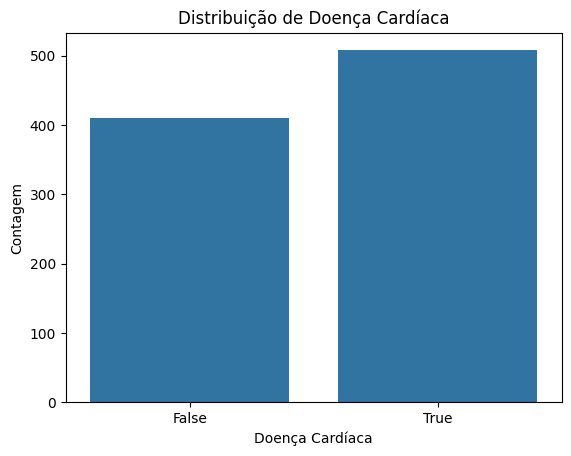

In [13]:
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribuição de Doença Cardíaca')
plt.xlabel('Doença Cardíaca')
plt.ylabel('Contagem')
plt.show()

### 4.2 Distribuicoes das Variaveis Numericas

**Objetivo:** Identificar a forma das distribuicoes separados por grupo alvo.


In [14]:
cores_Bool = {True: 'red', False: 'limegreen'}

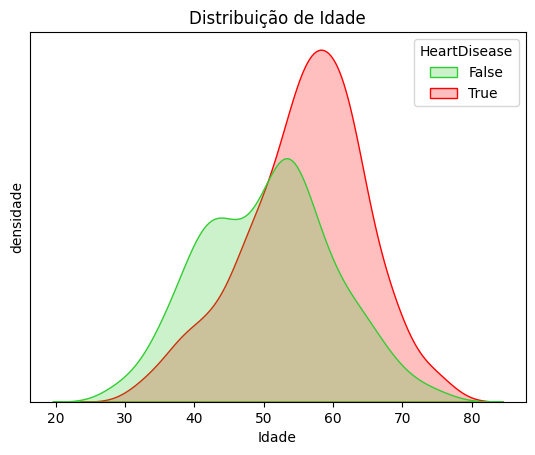

In [15]:

sns.kdeplot(data=df, x='Age', hue='HeartDisease', palette=cores_Bool, fill=True)
plt.title('Distribuição de Idade')
plt.yticks([])
plt.xlabel('Idade')
plt.ylabel('densidade')
plt.show()


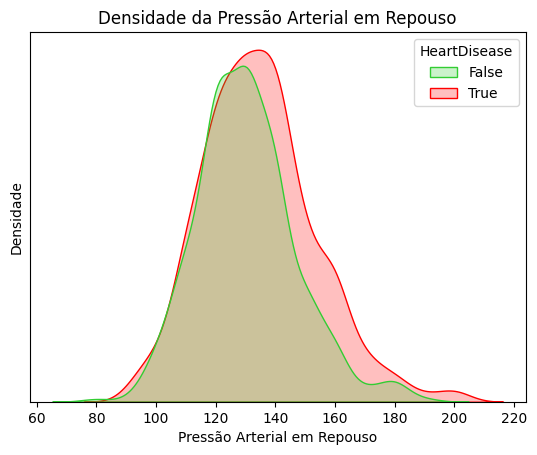

In [16]:

sns.kdeplot(data=df, x='RestingBP', hue='HeartDisease', palette=cores_Bool, fill=True)
plt.title('Densidade da Pressão Arterial em Repouso')
plt.yticks([])
plt.xlabel('Pressão Arterial em Repouso')
plt.ylabel('Densidade')
plt.show()

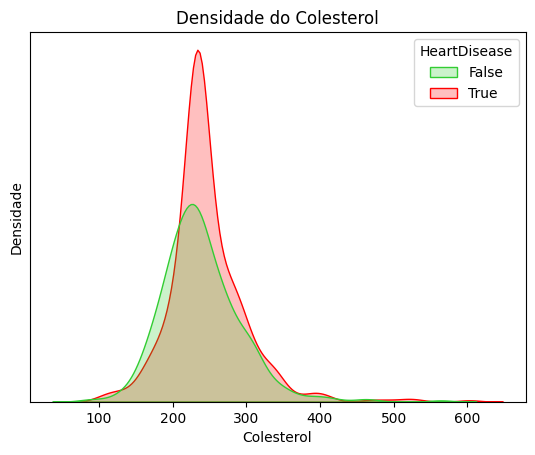

In [17]:
sns.kdeplot(x='Cholesterol', hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade do Colesterol')
plt.xlabel('Colesterol')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

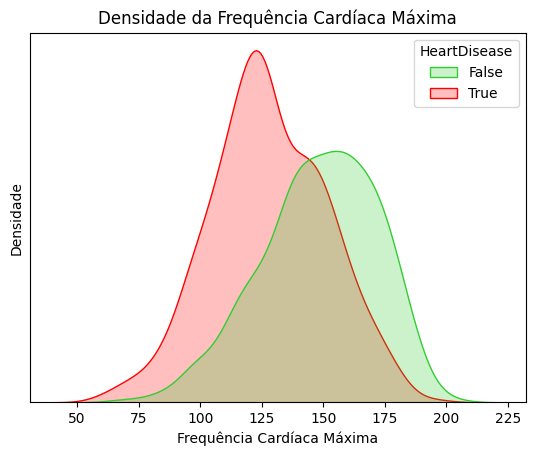

In [18]:
sns.kdeplot(x='MaxHR', hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade da Frequência Cardíaca Máxima')
plt.xlabel('Frequência Cardíaca Máxima')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

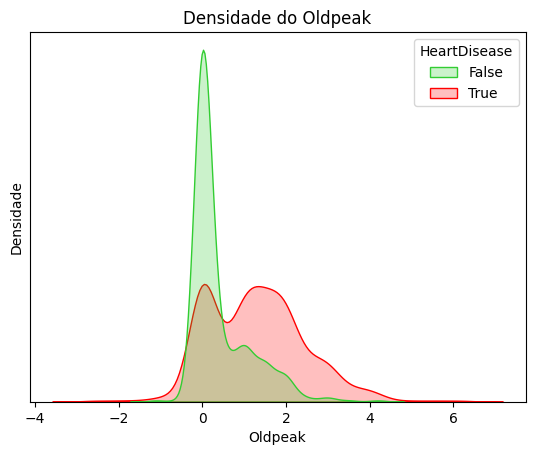

In [19]:
sns.kdeplot(x='Oldpeak', hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade do Oldpeak')
plt.xlabel('Oldpeak')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

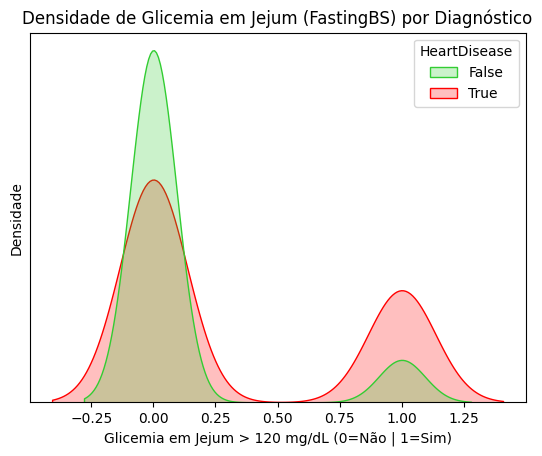

In [20]:
sns.kdeplot(x='FastingBS', hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade de Glicemia em Jejum (FastingBS) por Diagnóstico')
plt.xlabel('Glicemia em Jejum > 120 mg/dL (0=Não | 1=Sim)')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()


### 4.3 Distribuicoes das Variaveis Quantitativas

**Objetivo:** Identificar a forma das distribuicoes separados por grupo alvo.

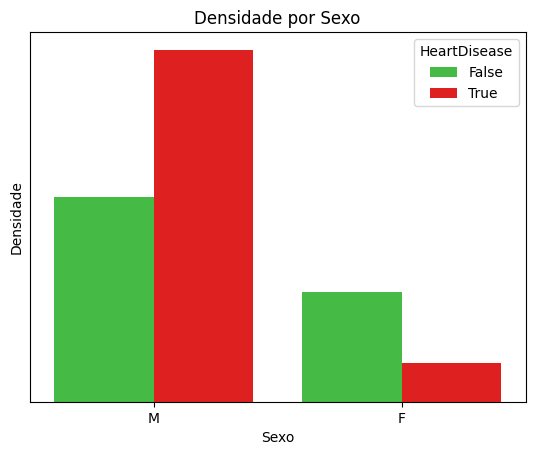

In [21]:
sns.countplot(x='Sex', hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

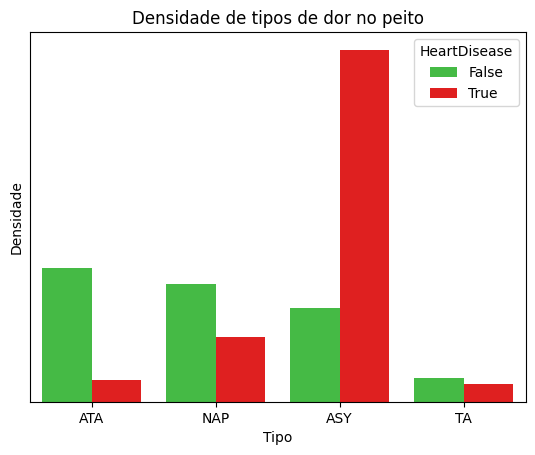

In [22]:
sns.countplot(x='ChestPainType',data=df,hue='HeartDisease',palette=cores_Bool,fill=True)
plt.title('Densidade de tipos de dor no peito')
plt.xlabel('Tipo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

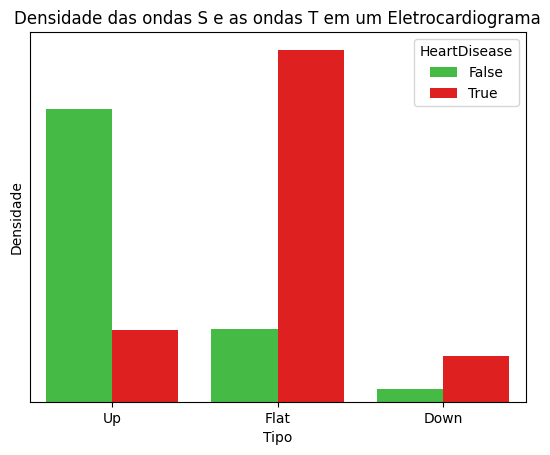

In [23]:
sns.countplot(x='ST_Slope',data=df,hue='HeartDisease',palette=cores_Bool,fill=True)
plt.title('Densidade das ondas S e as ondas T em um Eletrocardiograma')
plt.xlabel('Tipo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

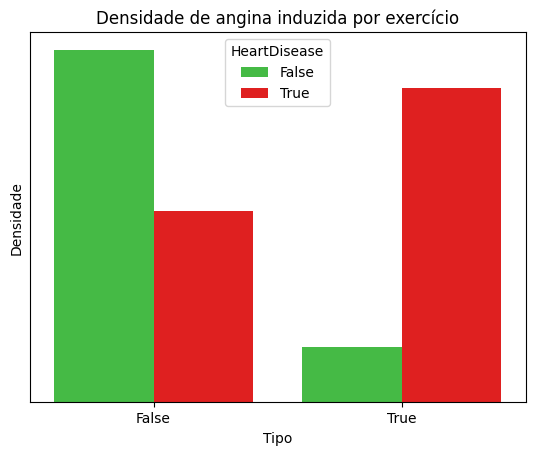

In [24]:
df['ExerciseAngina'] = df['ExerciseAngina'].map({'N': False, 'Y': True})
sns.countplot(x='ExerciseAngina',data=df,hue='HeartDisease',palette=cores_Bool,fill=True)
plt.title('Densidade de angina induzida por exercício')
plt.xlabel('Tipo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

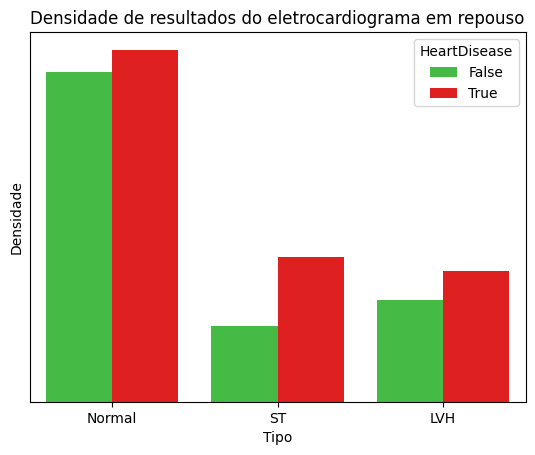

In [25]:
sns.countplot(x='RestingECG',data=df,hue='HeartDisease',palette=cores_Bool,fill=True)  
plt.title('Densidade de resultados do eletrocardiograma em repouso')
plt.xlabel('Tipo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

### 4.4 Mapa de correlação ###
**Objetivo: identificar possíves correlações no dataset**

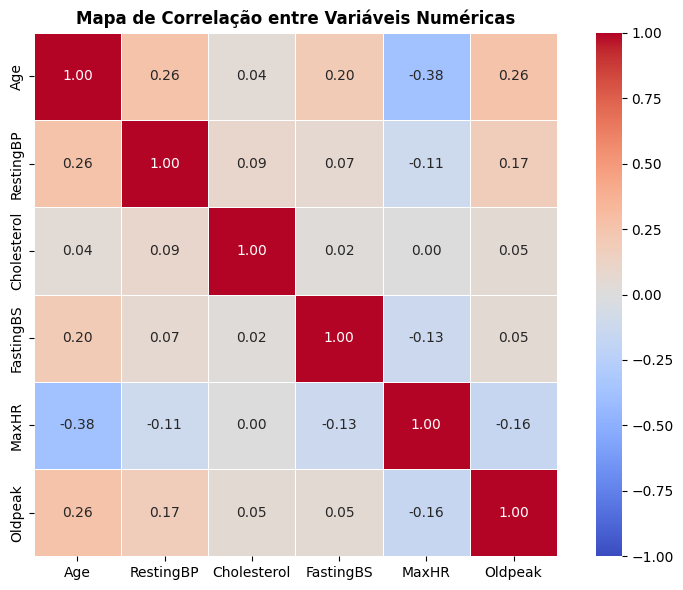

In [26]:
correlacao = df.select_dtypes(include='number').corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Mapa de Correlação entre Variáveis Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()


### 4.5 INSIGHTS GERADOS PELO EDA: ###

* **Oldpeak (Depressão do Segmento ST) — Correlação: +0.40**
    * Pacientes com doença têm um Oldpeak médio de 1,3, comparado a 0,4 nos saudáveis.
    * **Oldpeak > 2:** Taxa de doença altíssima de **91%** (amostra de 100 pacientes).
* **MaxHR (Frequência Cardíaca Máxima) — Correlação: −0.40**
    * Pacientes com doença atingem FC máxima média de 127,7 bpm vs. 148,2 bpm nos saudáveis (uma diferença significativa de ~20 bpm).
    * Esse padrão de déficit cronotrópico se repete inalterado em todas as faixas etárias.
* **ST_Slope (Inclinação do Segmento ST)**
    * **Slope Flat:** 83% de taxa de doença.
    * **Slope Down:** 78% de taxa de doença.
    * **Slope Up:** Apenas 20% de taxa de doença (atua como um forte sinal protetor).
* **ExerciseAngina (Angina induzida por Exercício)**
    * **Com angina:** 85% de taxa de doença.
    * **Sem angina:** 35% de taxa de doença.
* **ChestPainType (Tipo de Dor Torácica)**
    * **ASY (Assintomático):** 79% — O quadro mais perigoso por ser silencioso.
    * **Outros:** ATA: 43%, NAP: 35%, TA: 14%. *(Nota: A dor Típica de Angina - TA - ironicamente apresenta menor taxa que a atípica no geral do dataset)*.
* **FastingBS (Glicemia em Jejum > 120 mg/dL)**
    * **Com elevação:** 79% de taxa de doença vs. 48% sem elevação.

---

## Diferenças por Sexo

* **Homens** têm uma taxa de doença de **63%**, contra **26%** nas **mulheres**.
* **Atenção ao viés amostral:** Há 725 homens e apenas 193 mulheres na base. A amostra feminina é pequena e claramente sub-representada.
* Mesmo o tipo de dor mais perigoso (ASY) tem uma taxa de doença muito diferente: 83% nos homens vs. 56% nas mulheres. Mulheres com dor ASY ainda têm alto risco, mas a diferença ressalta a assimetria do dataset.

---

## Faixa Etária

| Faixa Etária | Taxa de Doença | Observação |
| :--- | :---: | :--- |
| **28–40 anos** | 34% | |
| **41–50 anos** | 42% | |
| **51–60 anos** | 58% | |
| **61–70 anos** | **74%** | **Pico de risco** |
| **71+ anos** | 67% | |

> **Nota:** O risco cresce monotonicamente até os 70 anos. O leve recuo na faixa dos 71+ pode ser atribuído a um **viés de sobrevivência** (pacientes muito frágeis com doença grave podem não chegar a realizar essa avaliação clínica).

---

## Combinações de Risco Críticas

Cruzamentos de variáveis apontam para subgrupos de altíssimo risco:

* **Dor ASY + ExerciseAngina = Y:** 297 pacientes com **90%** de taxa de doença.
* **ST_Slope (Flat ou Down) + ExerciseAngina = Y:** 313 pacientes com **90,7%** de taxa de doença.

### Score de Risco Combinado
Criando um score simples de 0 a 5 com os seguintes fatores críticos: Angina presente, Slope anormal (Flat/Down), Dor ASY, Glicemia alta, e Oldpeak > 1,5.

| Score | Taxa de Doença | N (Pacientes) |
| :---: | :---: | :---: |
| **0** | 4% | 210 |
| **1** | 27% | 168 |
| **2** | 66% | 161 |
| **3** | 87% | 207 |
| **4** | **97%** | 145 |
| **5** | **96%** | 27 |

**Conclusão Clínica:** Pacientes que apresentam 4 ou mais desses fatores têm um risco virtualmente certo (acima de 96%). É uma excelente regra clínica simples extraída dos dados.

---

## Colesterol — O Paradoxo Inverso

* Pacientes com doença têm um colesterol médio **mais baixo (175,9)** do que os pacientes saudáveis (227,1).
* **Por que isso acontece?** Isso é contraintuitivo, mas reflete dois prováveis artefatos dos dados:
    1. Muitos valores "0" foram imputados diretamente para pacientes doentes.
    2. Pacientes com histórico cardíaco frequentemente já estão em tratamento intensivo com hipolipemiantes (estatinas).
* A correlação negativa (−0.23) com a doença deve ser interpretada com extrema cautela pelo modelo.

---

## Insights para Modelagem

* **Feature Selection:** As variáveis `Oldpeak`, `MaxHR`, `ExerciseAngina`, `ST_Slope` e `ChestPainType` são as mais discriminativas da base. Elas devem ter a maior importância (*feature importance*) em qualquer modelo treinado.
* **Escolha do Algoritmo:** O sucesso do *Score de Risco* simples de 5 variáveis na separação das classes sugere que **modelos lineares** (como Regressão Logística) ou **probabilísticos simples** (como Naive Bayes) já terão um excelente desempenho e alta interpretabilidade.
* **Tratamento de Ruído:** O `Cholesterol` com zeros imputados pode estar inserindo ruído nas predições. É recomendado testar o treinamento do modelo com e sem essa variável.
* **Ações recomendadas para o pipeline:**
    * Plotar a Curva ROC-AUC.
    * Extrair o gráfico de *Feature Importance* (ex: de um Random Forest ou XGBoost).
    * Aplicar validação cruzada (Cross-Validation) **estratificada por sexo**, dado o forte desbalanceamento da amostra feminina.

### 5.0 Análise de probabilidade com o Teorema de Bayes

***5.1 PROBABILIDADES A PRIORI P(C)***

In [27]:
classes = [False, True]
features_num = ['Age', 'MaxHR', 'Oldpeak']
features_cat = ['Sex', 'ChestPainType', 'ExerciseAngina', 'ST_Slope']
total = len(df)
priori = {}

for c in classes:
    priori[c] = (df['HeartDisease'] == c).sum() / total
 
print("Probabilidades A Priori P(C)")
print(f"P(HeartDisease=False) = {priori[False]:.4f} ({priori[False]:.1%})")
print(f"P(HeartDisease=True)  = {priori[True]:.4f} ({priori[True]:.1%})")


Probabilidades A Priori P(C)
P(HeartDisease=False) = 0.4466 (44.7%)
P(HeartDisease=True)  = 0.5534 (55.3%)


**5.2 PARAMETROS GAUSSIANOS (media e desvio por classes)**

In [28]:
params_gauss = {}
print("\n=== Parametros Gaussianos por Classe ===")
for c in classes:
    subset = df[df['HeartDisease'] == c]
    params_gauss[c] = {}
    for feat in features_num:
        mu    = subset[feat].mean()
        sigma = subset[feat].std()
        params_gauss[c][feat] = (mu, sigma)
        print(f"  {feat:10s} | classe={str(c):5s} -> media={mu:.2f}, desvio={sigma:.2f}")


=== Parametros Gaussianos por Classe ===
  Age        | classe=False -> media=50.55, desvio=9.44
  MaxHR      | classe=False -> media=148.15, desvio=23.29
  Oldpeak    | classe=False -> media=0.41, desvio=0.70
  Age        | classe=True  -> media=55.90, desvio=8.73
  MaxHR      | classe=True  -> media=127.66, desvio=23.39
  Oldpeak    | classe=True  -> media=1.27, desvio=1.15


**5.3 PROBABILIDADES CATEGORICAS com Laplace**

In [31]:
probs_cat = {}
print("=" * 65)
print("  PROBABILIDADES CATEGORICAS P(x|C) com Suavizacao de Laplace")
print("=" * 65)

for feat in features_cat:
    k = df[feat].nunique()
    print(f"\nVariavel: {feat}  (k={k} categorias)")
    print(f"  {'Valor':<18s} {'P(x | Saudavel)':<22s} {'P(x | Doente)'}")
    print(f"  {'-'*18} {'-'*22} {'-'*15}")

    for c in [False, True]:
        subset   = df[df['HeartDisease'] == c]
        contagem = subset[feat].value_counts()
        total_c  = len(subset)
        probs_cat.setdefault(c, {}).setdefault(feat, {})
        for val in df[feat].unique():
            probs_cat[c][feat][val] = (contagem.get(val, 0) + 1) / (total_c + k)

    for val in sorted(df[feat].unique(), key=str):
        p_s = probs_cat[False][feat][val]
        p_d = probs_cat[True][feat][val]
        print(f"  {str(val):<18s} {p_s:.4f} ({p_s:.1%})          {p_d:.4f} ({p_d:.1%})")

print()
print("=" * 65)


  PROBABILIDADES CATEGORICAS P(x|C) com Suavizacao de Laplace

Variavel: Sex  (k=2 categorias)
  Valor              P(x | Saudavel)        P(x | Doente)
  ------------------ ---------------------- ---------------
  F                  0.3495 (35.0%)          0.1000 (10.0%)
  M                  0.6505 (65.0%)          0.9000 (90.0%)

Variavel: ChestPainType  (k=4 categorias)
  Valor              P(x | Saudavel)        P(x | Doente)
  ------------------ ---------------------- ---------------
  ASY                0.2536 (25.4%)          0.7676 (76.8%)
  ATA                0.3623 (36.2%)          0.0488 (4.9%)
  NAP                0.3188 (31.9%)          0.1426 (14.3%)
  TA                 0.0652 (6.5%)          0.0410 (4.1%)

Variavel: ExerciseAngina  (k=2 categorias)
  Valor              P(x | Saudavel)        P(x | Doente)
  ------------------ ---------------------- ---------------
  False              0.8641 (86.4%)          0.3784 (37.8%)
  True               0.1359 (13.6%)          0.

**5.4 VEROSSIMILHANCA GAUSSIANA**

In [32]:

def verossimilhanca_gaussiana(x, mu, sigma):
    coeficiente = 1.0 / (np.sqrt(2 * np.pi) * sigma)
    expoente    = -((x - mu) ** 2) / (2 * sigma ** 2)
    return coeficiente * np.exp(expoente)

**5.5 FUNCAO DE PREDICAO BAYESIANA**

In [33]:

def prever_bayes(amostra):
    log_posteriors = {}
 
    for c in classes:
        # Inicia com o log da probabilidade a priori
        log_prob = np.log(priori[c])
 
        # Log das verossimilhancas continuas (gaussiana)
        for feat in features_num:
            mu, sigma = params_gauss[c][feat]
            lk = verossimilhanca_gaussiana(amostra[feat], mu, sigma)
            lk = max(lk, 1e-300)   # evitar log(0)
            log_prob += np.log(lk)
 
        # Log das verossimilhancas categoricas (Laplace)
        for feat in features_cat:
            val  = amostra[feat]
            prob = probs_cat[c][feat].get(val, 1e-10)
            log_prob += np.log(prob)
 
        log_posteriors[c] = log_prob
 
    # Converter de log para probabilidade normalizada
    max_log   = max(log_posteriors.values())
    exp_probs = {c: np.exp(log_posteriors[c] - max_log) for c in classes}
    soma      = sum(exp_probs.values())
    return {c: exp_probs[c] / soma for c in classes}
 

**5.6 Aplicação da formúla**

**5.6 Probabilidades A Posteriori P(C|X) -- Aplicacao do Teorema de Bayes**

In [34]:
# Tres perfis de pacientes para aplicar o Teorema de Bayes
pacientes = {
    'Paciente A -- Alto Risco': {
        'Age': 65, 'MaxHR': 110, 'Oldpeak': 2.5,
        'Sex': 'M', 'ChestPainType': 'ASY',
        'ExerciseAngina': False, 'ST_Slope': 'Flat'
    },
    'Paciente B -- Risco Moderado': {
        'Age': 52, 'MaxHR': 138, 'Oldpeak': 1.0,
        'Sex': 'M', 'ChestPainType': 'NAP',
        'ExerciseAngina': False, 'ST_Slope': 'Flat'
    },
    'Paciente C -- Baixo Risco': {
        'Age': 40, 'MaxHR': 165, 'Oldpeak': 0.0,
        'Sex': 'F', 'ChestPainType': 'ATA',
        'ExerciseAngina': False, 'ST_Slope': 'Up'
    },
}

print('O Teorema de Bayes combina a probabilidade a priori P(C)')
print('com a verossimilhanca P(X|C) para gerar a probabilidade')
print('a posteriori P(C|X) -- a probabilidade final do diagnostico.')
print('Formula: P(C|X) proporcional P(C) * P(X|C)')
print('=' * 60)

for nome, paciente in pacientes.items():
    resultado = prever_bayes(paciente)
    pred      = max(resultado, key=resultado.get)
    confianca = resultado[pred]

    print(f'\nPerfil: {nome}')
    print('  Atributos:')
    for k, v in paciente.items():
        print(f'    {k}: {v}')

    print(f'\n  Probabilidades A Posteriori P(C|X):')
    print(f'    P(Sem Doenca | X) = {resultado[False]:.4f}  ({resultado[False]:.1%})')
    print(f'    P(Com Doenca | X) = {resultado[True]:.4f}  ({resultado[True]:.1%})')
    print(f'\n  Predicao: {"COM doenca" if pred else "SEM doenca"}')
    print(f'  Confianca: {confianca:.1%}')

    print('\n  Interpretacao:')
    if pred == True and confianca > 0.85:
        print('    Alta probabilidade de doenca cardiaca.')
        print('    Fatores dominantes: dor assintomatica (ASY),')
        print('    angina por exercicio e declive ST flat/down.')
    elif pred == True and confianca <= 0.85:
        print('    Probabilidade moderada de doenca cardiaca.')
        print('    Evidencias contraditórias -- investigacao adicional recomendada.')
    else:
        print('    Baixa probabilidade de doenca cardiaca.')
        print('    MaxHR elevado, sem angina e ST ascendente (Up)')
        print('    sao indicadores favoraveis.')
    print('-' * 60)


O Teorema de Bayes combina a probabilidade a priori P(C)
com a verossimilhanca P(X|C) para gerar a probabilidade
a posteriori P(C|X) -- a probabilidade final do diagnostico.
Formula: P(C|X) proporcional P(C) * P(X|C)

Perfil: Paciente A -- Alto Risco
  Atributos:
    Age: 65
    MaxHR: 110
    Oldpeak: 2.5
    Sex: M
    ChestPainType: ASY
    ExerciseAngina: False
    ST_Slope: Flat

  Probabilidades A Posteriori P(C|X):
    P(Sem Doenca | X) = 0.0007  (0.1%)
    P(Com Doenca | X) = 0.9993  (99.9%)

  Predicao: COM doenca
  Confianca: 99.9%

  Interpretacao:
    Alta probabilidade de doenca cardiaca.
    Fatores dominantes: dor assintomatica (ASY),
    angina por exercicio e declive ST flat/down.
------------------------------------------------------------

Perfil: Paciente B -- Risco Moderado
  Atributos:
    Age: 52
    MaxHR: 138
    Oldpeak: 1.0
    Sex: M
    ChestPainType: NAP
    ExerciseAngina: False
    ST_Slope: Flat

  Probabilidades A Posteriori P(C|X):
    P(Sem Doenca | 

**5.7 Avaliacao das Metricas -- Naive Bayes no Dataset Completo**

=== Avaliacao -- Naive Bayes (implementado do zero) ===
  Verdadeiros Positivos (TP): 436
  Verdadeiros Negativos (TN): 341
  Falsos Positivos      (FP): 69  <- previu doenca, mas nao tinha
  Falsos Negativos      (FN): 72  <- nao previu doenca, mas tinha

  Acuracia : 0.8464  -- proporcao de acertos totais
  Precisao : 0.8634  -- dos que previu positivo, quantos eram positivos
  Recall   : 0.8583  -- dos que eram positivos, quantos o modelo achou
  F1-Score : 0.8608  -- media harmonica entre precisao e recall


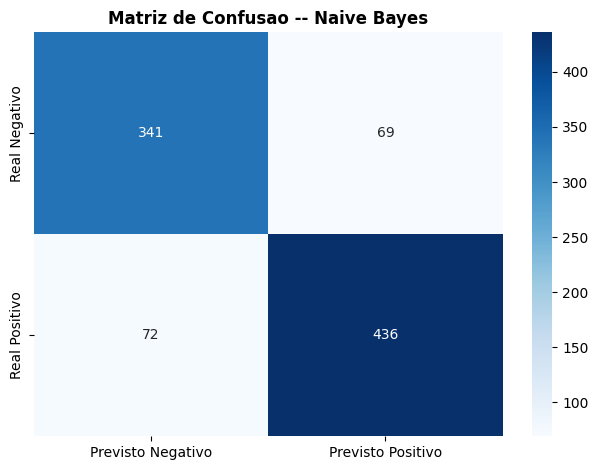

In [35]:
# Aplicar o modelo em todos os registros do dataset
y_pred_bayes = []
for _, row in df.iterrows():
    amostra   = {f: row[f] for f in features_num + features_cat}
    resultado = prever_bayes(amostra)
    y_pred_bayes.append(resultado[True] >= 0.5)

y_pred_bayes = np.array(y_pred_bayes).astype(int)
y_real       = df['HeartDisease'].values.astype(int)

# Calcular metricas do zero
TP = int(((y_pred_bayes == 1) & (y_real == 1)).sum())
TN = int(((y_pred_bayes == 0) & (y_real == 0)).sum())
FP = int(((y_pred_bayes == 1) & (y_real == 0)).sum())
FN = int(((y_pred_bayes == 0) & (y_real == 1)).sum())

acuracia = (TP + TN) / (TP + TN + FP + FN)
precisao = TP / (TP + FP) if (TP + FP) > 0 else 0
recall   = TP / (TP + FN) if (TP + FN) > 0 else 0
f1       = 2 * precisao * recall / (precisao + recall) if (precisao + recall) > 0 else 0

print('=== Avaliacao -- Naive Bayes (implementado do zero) ===')
print(f'  Verdadeiros Positivos (TP): {TP}')
print(f'  Verdadeiros Negativos (TN): {TN}')
print(f'  Falsos Positivos      (FP): {FP}  <- previu doenca, mas nao tinha')
print(f'  Falsos Negativos      (FN): {FN}  <- nao previu doenca, mas tinha')
print()
print(f'  Acuracia : {acuracia:.4f}  -- proporcao de acertos totais')
print(f'  Precisao : {precisao:.4f}  -- dos que previu positivo, quantos eram positivos')
print(f'  Recall   : {recall:.4f}  -- dos que eram positivos, quantos o modelo achou')
print(f'  F1-Score : {f1:.4f}  -- media harmonica entre precisao e recall')

matriz_df = pd.DataFrame(
    [[TN, FP], [FN, TP]],
    index=['Real Negativo', 'Real Positivo'],
    columns=['Previsto Negativo', 'Previsto Positivo']
)

sns.heatmap(matriz_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusao -- Naive Bayes', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Algoritmos de Classificação

### 6.1 Pré-processamento: Engenharia de Atributos e Divisão dos Conjuntos
Para alimentar os modelos de Machine Learning do Scikit-Learn, realizamos:
1. **One-Hot Encoding (Dummies):** Conversão de variáveis qualitativas nominais em representações numéricas binárias (0 e 1).
2. **Divisão Treino/Teste:** Divisão estratificada (70/30) para garantir a mesma proporção de doentes em ambas as partições.
3. **Padronização Escalar (StandardScaler):** Essencial para o KNN, pois transforma as variáveis contínuas de modo que nenhuma domina o cálculo de distância por ter escala maior.


In [36]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)

In [37]:
X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [39]:
scaler = StandardScaler()

In [40]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
print("Dados preparados com sucesso!")
print(f"Amostras de treino: {X_train.shape[0]} | Amostras de teste: {X_test.shape[0]}")

Dados preparados com sucesso!
Amostras de treino: 642 | Amostras de teste: 276


### 6.2 Modelo K-Nearest Neighbors (KNN)
O KNN classifica uma nova observação com base na classe mais frequente entre os seus $K$ vizinhos mais próximos.
* **Hiperparâmetro definido:** $K = 5$ (número padrão e robusto para evitar ruído ou fronteiras de decisão demasiado complexas).
* **Métrica de Distância:** Distância Euclidiana calculada sobre as variáveis previamente normalizadas pelo `StandardScaler`.


In [42]:
knn = KNeighborsClassifier(n_neighbors=5)

In [43]:
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[bool](2,)","[False, True]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [44]:
y_pred_knn = knn.predict(X_test_scaled)

In [45]:
metrics_knn = {
    'Acurácia': accuracy_score(y_test, y_pred_knn),
    'Precisão': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn)
}


In [46]:
print("=== MÉTRICAS - KNN ===")
for k, v in metrics_knn.items():
    print(f"{k}: {v:.4f}")


=== MÉTRICAS - KNN ===
Acurácia: 0.8913
Precisão: 0.8917
Recall: 0.9150
F1-Score: 0.9032


#### Matriz de Confusão — KNN
A Matriz de Confusão permite cruzar os valores reais da variável alvo com as previsões efetuadas pelo algoritmo. Através do mapa de calor (Heatmap), conseguimos analisar visualmente a ocorrência de:
* **Verdadeiros Negativos (TN) e Verdadeiros Positivos (TP):** Acertos do classificador.
* **Falsos Positivos (FP):** Erros do tipo I (alarme falso).
* **Falsos Negativos (FN):** Erros do tipo II — clinicamente perigosos, pois deixam passar pacientes doentes.


In [47]:
matriz_knn = confusion_matrix(y_test, y_pred_knn)



In [48]:
matriz_df = pd.DataFrame(
    matriz_knn,
    index=['Real Saudável (0)', 'Real Doente (1)'],
    columns=['Previsto Saudável (0)', 'Previsto Doente (1)']
)
print("\n=== MATRIZ DE CONFUSÃO ===")
print(matriz_df)


=== MATRIZ DE CONFUSÃO ===
                   Previsto Saudável (0)  Previsto Doente (1)
Real Saudável (0)                    106                   17
Real Doente (1)                       13                  140


### 6.3 Modelo Árvore de Decisão
Ao contrário do KNN, a Árvore de Decisão é um modelo estruturado em regras lógicas de partição.
* **Configuração:** Limitamos o crescimento da árvore com `max_depth=4` para evitar o fenômeno de *overfitting* (sobreajuste aos dados de treino) e garantir que a visualização final seja totalmente interpretável.
* **Vantagem:** Não requer normalização dos dados (ao contrário do KNN), pois as partições são baseadas em limiares de valor, não em distâncias.


In [49]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)

In [50]:
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [51]:
y_pred_dt = dt.predict(X_test)

In [52]:
metrics_dt = {
    'Acurácia': accuracy_score(y_test, y_pred_dt),
    'Precisão': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt)
}


In [53]:
print("=== MÉTRICAS - ÁRVORE DE DECISÃO ===")
for k, v in metrics_dt.items():
    print(f"{k}: {v:.4f}")

=== MÉTRICAS - ÁRVORE DE DECISÃO ===
Acurácia: 0.7862
Precisão: 0.8092
Recall: 0.8039
F1-Score: 0.8066


### 6.4 Comparação Consolidada: Naive Bayes vs KNN vs Árvore de Decisão
Consolidamos as métricas de todos os classificadores para análise comparativa:
1. **Naive Bayes (Manual):** Modelo probabilístico implementado do zero, sem bibliotecas de ML.
2. **KNN (K=5):** Classificador baseado em distância euclidiana.
3. **Árvore de Decisão (Profundidade=4):** Classificador baseado em regras lógicas de partição.


=== TABELA COMPARATIVA DE DESEMPENHO ===


Métrica,Naive Bayes (Manual),KNN (K=5),Árvore de Decisão
Acurácia,84.06%,89.13%,78.62%
Precisão,85.29%,89.17%,80.92%
Recall,86.57%,91.50%,80.39%
F1-Score,85.93%,90.32%,80.66%


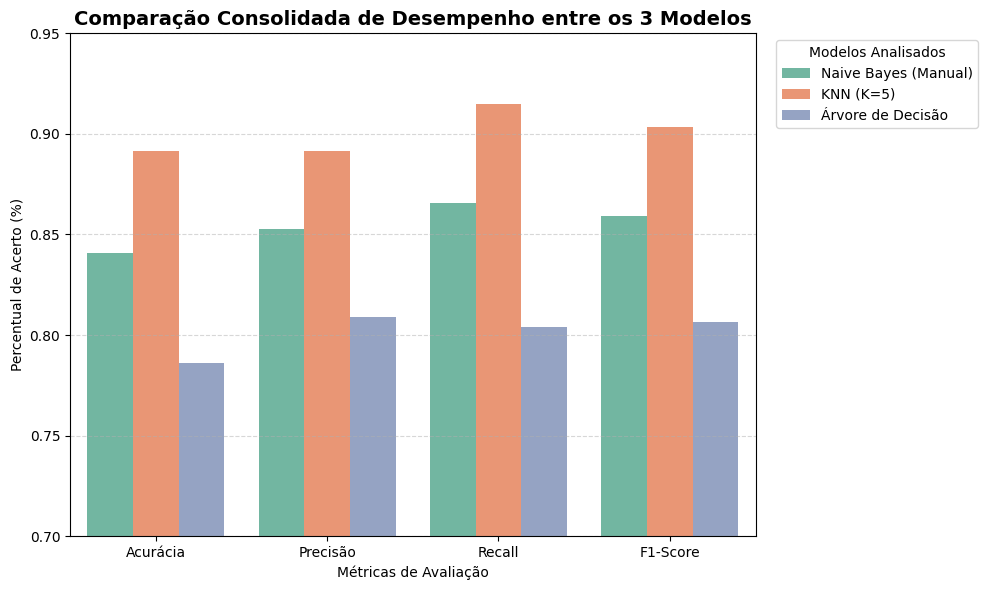

In [54]:
# 1. Definir os valores obtidos no seu Naive Bayes manual
# (Atualize estas variáveis se as suas métricas calculadas no Naive Bayes forem ligeiramente diferentes)
acuracia_nb = 0.8406
precisao_nb = 0.8529
recall_nb = 0.8657
f1_nb = 0.8593

# 2. Estruturar o dicionário de dados unificado
dados_comparativos = {
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Naive Bayes (Manual)': [acuracia_nb, precisao_nb, recall_nb, f1_nb],
    'KNN (K=5)': [metrics_knn['Acurácia'], metrics_knn['Precisão'], metrics_knn['Recall'], metrics_knn['F1-Score']],
    'Árvore de Decisão': [metrics_dt['Acurácia'], metrics_dt['Precisão'], metrics_dt['Recall'], metrics_dt['F1-Score']]
}

# 3. Criar e formatar o DataFrame comparativo
df_comparacao = pd.DataFrame(dados_comparativos)

print("=== TABELA COMPARATIVA DE DESEMPENHO ===")
# Exibe a tabela formatando os valores numéricos como porcentagem elegante
display(df_comparacao.style.format({
    'Naive Bayes (Manual)': '{:.2%}',
    'KNN (K=5)': '{:.2%}',
    'Árvore de Decisão': '{:.2%}'
}).hide(axis='index'))

# 4. Transformar o formato da tabela para facilitar a plotagem no Seaborn (Melt)
df_melted = df_comparacao.melt(id_vars='Métrica', var_name='Modelo', value_name='Pontuação')

# 5. Plotar o gráfico de barras comparativo lado a lado
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Métrica', y='Pontuação', hue='Modelo', palette='Set2')

# Ajustes estéticos do gráfico
plt.title('Comparação Consolidada de Desempenho entre os 3 Modelos', fontsize=14, fontweight='bold')
plt.ylabel('Percentual de Acerto (%)')
plt.xlabel('Métricas de Avaliação')
plt.ylim(0.70, 0.95)  # Foca o zoom gráfico entre 70% e 95% para destacar as diferenças
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Modelos Analisados')
plt.tight_layout()
plt.show()